In [1]:
import numpy as np
import json
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import fisherz
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.graph.GraphNode import GraphNode
import time

X_pc_full_ea = np.load(r"C:\Users\user\Downloads\GSE148812_clean\v2_pc_input.npy")
with open(r"C:\Users\user\Downloads\GSE148812_clean\v2_pc_col_names.json") as f:
    col_names_ea = json.load(f)

n_nodes = len(col_names_ea)
smoking_idx = col_names_ea.index("smoking_status")
print("Input shape:", X_pc_full_ea.shape)

bk = BackgroundKnowledge()
nodes = [GraphNode(name) for name in col_names_ea]
for i in range(n_nodes - 1):
    bk.add_node_to_tier(nodes[i], 0)
bk.add_node_to_tier(nodes[smoking_idx], 1)

start = time.time()
cg = pc(
    data=X_pc_full_ea,
    alpha=0.001,
    indep_test=fisherz,
    stable=True,
    uc_rule=0,
    uc_priority=2,
    background_knowledge=bk,
    verbose=False,
    show_progress=True,
    node_names=col_names_ea
)
elapsed = time.time() - start
print(f"Completed in {elapsed:.1f}s")
print("Nodes:", len(cg.G.nodes))

c:\Users\user\Desktop\ai causal\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Input shape: (1595, 19)


Depth=5, working on node 18: 100%|██████████| 19/19 [00:00<00:00, 926.68it/s]


Completed in 0.8s
Nodes: 19


In [2]:
import networkx as nx
import pandas as pd

adj = cg.G.graph
n_nodes = len(col_names_ea)
smoking_idx = col_names_ea.index("smoking_status")

edges_directed = []
edges_undirected = []

for i in range(n_nodes):
    for j in range(i+1, n_nodes):
        if adj[i,j] == -1 and adj[j,i] == 1:
            edges_directed.append((col_names_ea[i], col_names_ea[j]))
        elif adj[i,j] == 1 and adj[j,i] == -1:
            edges_directed.append((col_names_ea[j], col_names_ea[i]))
        elif adj[i,j] == -1 and adj[j,i] == -1:
            edges_undirected.append((col_names_ea[i], col_names_ea[j]))

print(f"Directed edges: {len(edges_directed)}")
print(f"Undirected edges: {len(edges_undirected)}")
print(f"\nReverse edges (smoking_status → SNP): {len([(u,v) for u,v in edges_directed if u=='smoking_status'])}")

print("\nEdges involving smoking_status:")
for u, v in edges_directed:
    if "smoking_status" in (u, v):
        print(f"  {u} → {v}")
for u, v in edges_undirected:
    if "smoking_status" in (u, v):
        print(f"  {u} --- {v} (undirected)")

# build ancestral subgraph
G = nx.DiGraph()
G.add_nodes_from(col_names_ea)
for u, v in edges_directed:
    G.add_edge(u, v)
G_reach = G.copy()
for u, v in edges_undirected:
    G_reach.add_edge(u, v)
    G_reach.add_edge(v, u)

ancestors = nx.ancestors(G_reach, "smoking_status")
ancestors.add("smoking_status")
print(f"\nAncestral subgraph nodes: {len(ancestors)}")

G_final_ea = nx.DiGraph()
G_final_ea.add_nodes_from(ancestors)
for u, v in edges_directed:
    if u in ancestors and v in ancestors:
        G_final_ea.add_edge(u, v)
for u, v in edges_undirected:
    if u in ancestors and v in ancestors:
        G_final_ea.add_edge(u, v, undirected=True)
        G_final_ea.add_edge(v, u, undirected=True)

print(f"Final graph — nodes: {G_final_ea.number_of_nodes()}, edges: {G_final_ea.number_of_edges()}")

Directed edges: 27
Undirected edges: 5

Reverse edges (smoking_status → SNP): 0

Edges involving smoking_status:
  exm935491-0_T_R_1918372056 → smoking_status
  exm793377-0_T_R_1922407882 → smoking_status

Ancestral subgraph nodes: 3
Final graph — nodes: 3, edges: 2


In [3]:
print("All directed edges:")
for u, v in edges_directed:
    print(f"  {u[:35]} → {v[:35]}")

print("\nAll undirected edges:")
for u, v in edges_undirected:
    print(f"  {u[:35]} --- {v[:35]}")

All directed edges:
  exm1071911-0_B_F_2060125197 → exm144193-0_B_R_2060145058
  exm144193-0_B_R_2060145058 → exm326114-0_T_R_1922190870
  exm144193-0_B_R_2060145058 → exm579132-0_T_R_1921991094
  exm935491-0_T_R_1918372056 → smoking_status
  exm289607-0_T_F_2060424793 → exm1006784-0_B_R_1922546096
  exm579132-0_T_R_1921991094 → exm1006784-0_B_R_1922546096
  exm2258344-0_T_R_1975252217 → exm1006784-0_B_R_1922546096
  exm684043-0_T_R_2060139530 → exm1006784-0_B_R_1922546096
  exm1215705-0_T_F_1921777411 → exm1071911-0_B_F_2060125197
  exm1071911-0_B_F_2060125197 → exm381233-0_T_R_1923050822
  exm1071911-0_B_F_2060125197 → exm503645-0_T_F_1921113766
  exm2258344-0_T_R_1975252217 → exm1071911-0_B_F_2060125197
  exm1215705-0_T_F_1921777411 → exm1094587-0_B_R_1922736292
  exm1094587-0_B_R_1922736292 → exm503645-0_T_F_1921113766
  exm1094587-0_B_R_1922736292 → exm579132-0_T_R_1921991094
  exm2258344-0_T_R_1975252217 → exm1094587-0_B_R_1922736292
  exm684043-0_T_R_2060139530 → exm1094587-0_B_

In [4]:
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import fisherz
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.graph.GraphNode import GraphNode
import time

# try alpha=0.05 — more lenient, more edges
for alpha_val in [0.05, 0.01, 0.005]:
    bk = BackgroundKnowledge()
    nodes = [GraphNode(name) for name in col_names_ea]
    for i in range(n_nodes - 1):
        bk.add_node_to_tier(nodes[i], 0)
    bk.add_node_to_tier(nodes[smoking_idx], 1)

    cg_test = pc(
        data=X_pc_full_ea,
        alpha=alpha_val,
        indep_test=fisherz,
        stable=True,
        uc_rule=0,
        uc_priority=2,
        background_knowledge=bk,
        verbose=False,
        show_progress=False,
        node_names=col_names_ea
    )

    adj_test = cg_test.G.graph
    smoking_edges = []
    for i in range(n_nodes):
        for j in range(n_nodes):
            if j == smoking_idx and adj_test[i,j] == -1 and adj_test[j,i] == 1:
                smoking_edges.append(col_names_ea[i])
            elif i == smoking_idx and adj_test[i,j] == -1 and adj_test[j,i] == -1:
                smoking_edges.append(f"{col_names_ea[j]} (undirected)")

    print(f"alpha={alpha_val}: {len(smoking_edges)} edges to smoking_status: {smoking_edges}")

alpha=0.05: 2 edges to smoking_status: ['exm935491-0_T_R_1918372056', 'exm793377-0_T_R_1922407882']
alpha=0.01: 2 edges to smoking_status: ['exm935491-0_T_R_1918372056', 'exm793377-0_T_R_1922407882']
alpha=0.005: 2 edges to smoking_status: ['exm935491-0_T_R_1918372056', 'exm793377-0_T_R_1922407882']


In [5]:
import requests
import time
import re

ea_network_nodes = [n for n in G_final_ea.nodes() if n != "smoking_status"]
ea_all_nodes = list(set([n for edge in edges_directed + edges_undirected for n in edge] + ["smoking_status"]))
ea_snp_nodes = [n for n in ea_all_nodes if n != "smoking_status"]

manifest_path = r"C:\Users\user\Downloads\HumanExome-12-v1-0-B.csv"
manifest_df = pd.read_csv(manifest_path, skiprows=7, low_memory=False)
manifest_df["core_name"] = manifest_df["IlmnID"].map(lambda x: re.sub(r'_\d+$', '', x))
pos_lookup = manifest_df.set_index("core_name")[["Chr", "MapInfo"]]

ann_rows = []
for pid in ea_snp_nodes:
    core = re.sub(r'_\d+$', '', pid)
    match = pos_lookup.loc[core] if core in pos_lookup.index else None
    if match is not None:
        ann_rows.append({
            "probe_id": pid,
            "Chr": str(match["Chr"]),
            "Position_bp": int(match["MapInfo"]) if pd.notna(match["MapInfo"]) else None
        })

ann_df_ea = pd.DataFrame(ann_rows)

def get_gene_ensembl(chrom, pos, window=50000):
    url = f"https://grch37.rest.ensembl.org/overlap/region/human/{chrom}:{pos-window}-{pos+window}"
    params = {"feature": "gene", "content-type": "application/json"}
    try:
        r = requests.get(url, params=params, timeout=15)
        if r.status_code != 200:
            return "?"
        genes = r.json()
        if not genes:
            return "intergenic"
        coding = [g for g in genes if g.get("biotype") == "protein_coding"]
        targets = coding if coding else genes
        names = list(set(g.get("external_name", "?") for g in targets))
        return " | ".join(names[:3])
    except:
        return "error"

print("Annotating EA network SNPs...")
gene_map_ea = {}
for _, row in ann_df_ea.iterrows():
    gene = get_gene_ensembl(row["Chr"], row["Position_bp"])
    gene_map_ea[row["probe_id"]] = gene
    print(f"  Chr{row['Chr']}:{row['Position_bp']} → {gene}")
    time.sleep(0.5)

Annotating EA network SNPs...
  Chr8:16850601 → MICU3 | FGF20
  Chr16:5097934 → ALG1 | NAGPA | SEC14L5
  Chr4:1656776 → SLBP | FAM53A
  Chr9:136291361 → SURF4 | REXO4 | C9orf96
  Chr13:73335638 → PIBF1 | MZT1 | DIS3
  Chr12:53207439 → KRT76 | KRT4 | KRT78
  Chr11:68562288 → MTL5 | CPT1A
  Chr7:43663184 → STK17A | COA1
  Chr1:207195568 → YOD1 | C1orf116 | PFKFB2
  Chr3:58088056 → FLNB
  Chr14:25043951 → CTSG | GZMH
  Chr6:132892143 → TAAR5 | TAAR2 | TAAR8
  Chr6:109886001 → AK9
  Chr3:10146173 → BRK1 | FANCD2OS | FANCD2
  Chr5:171532728 → STK10


C:\Users\user\AppData\Local\Temp\ipykernel_13392\3623093817.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(unique_chroms_ea))


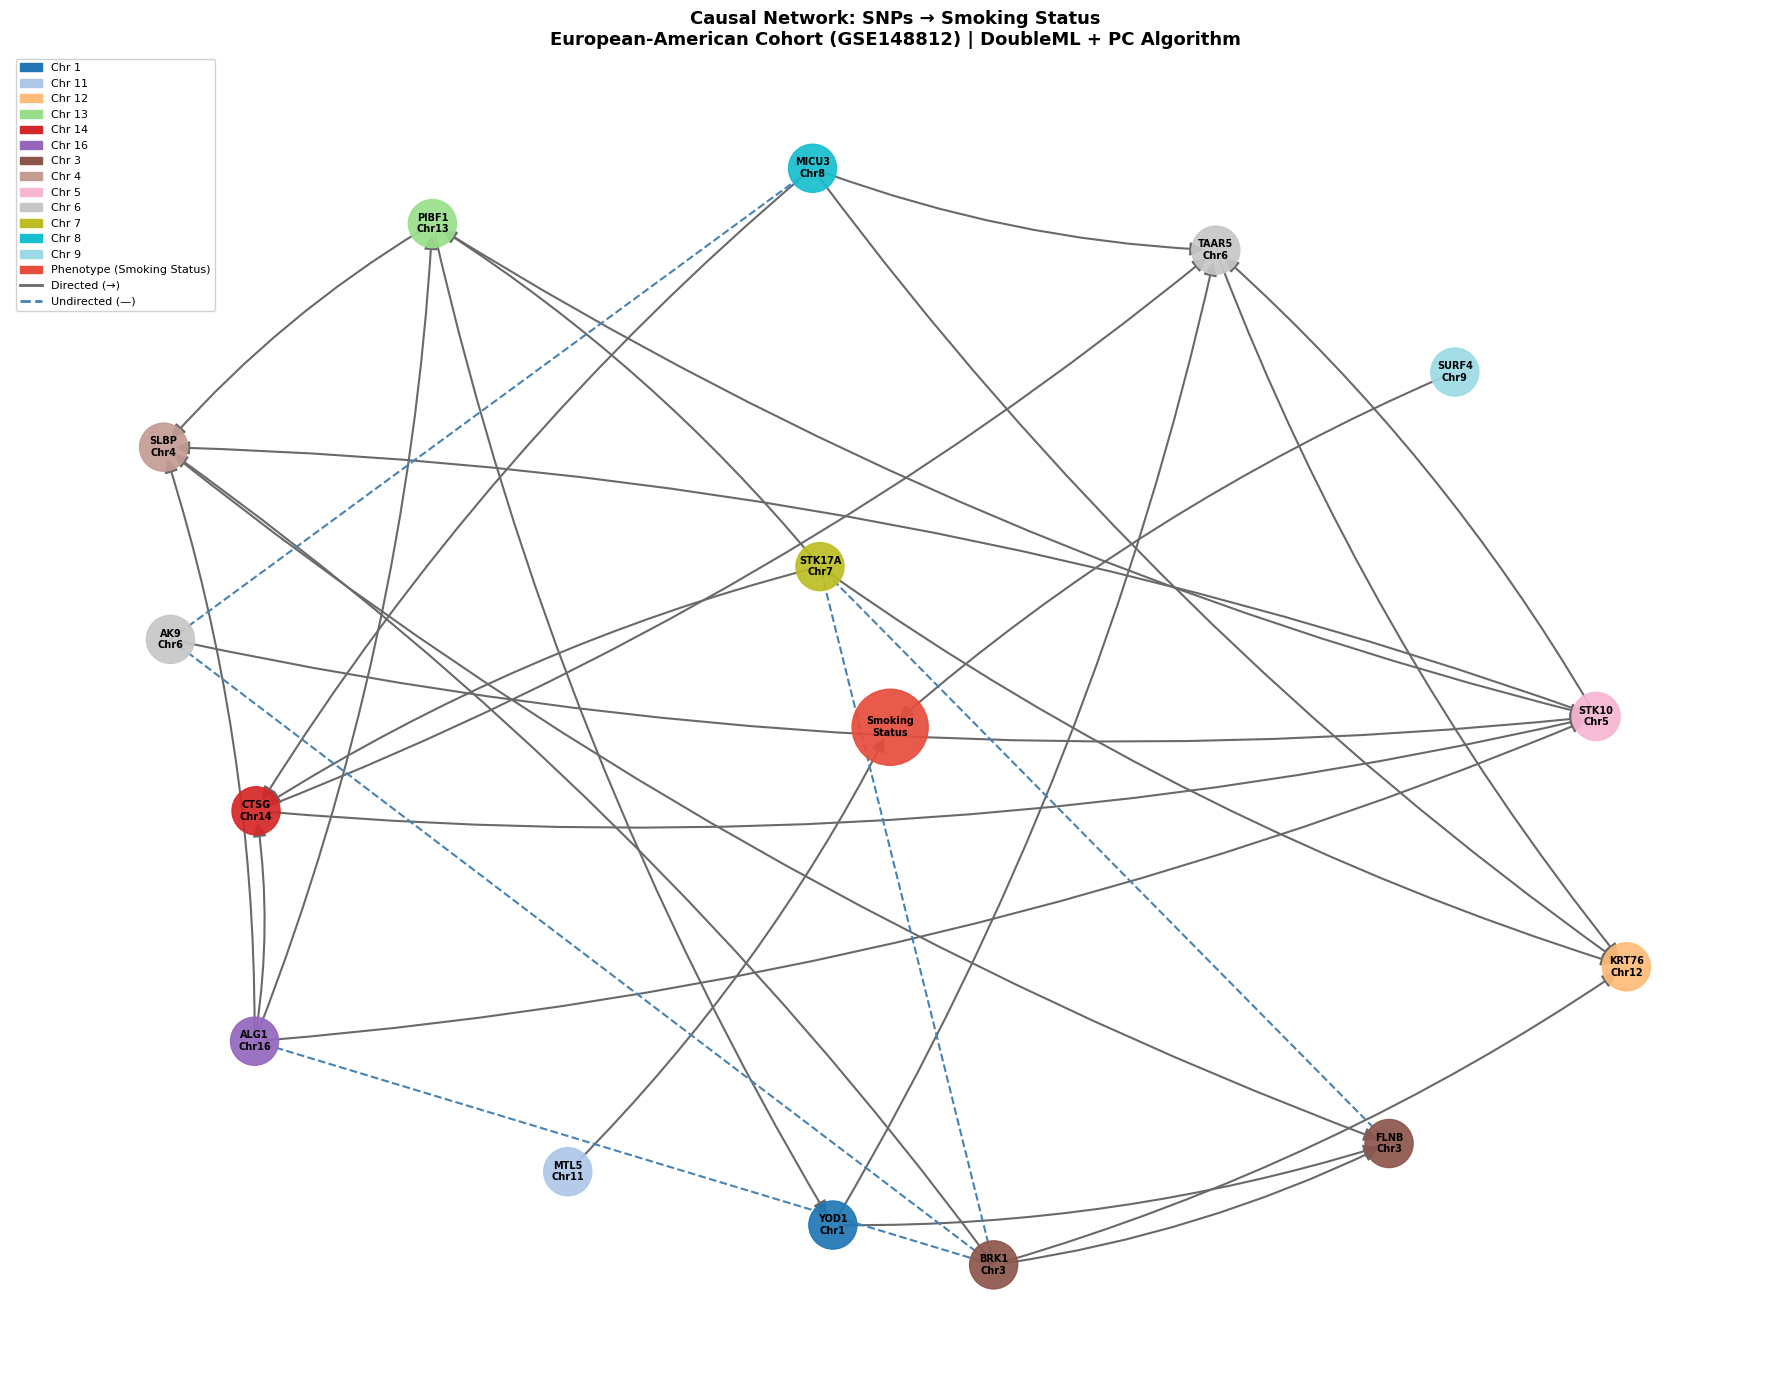

Saved: C:\Users\user\Downloads\GSE148812_clean\v2_causal_network_EA.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import re

# build full graph (all 18 SNPs + smoking_status)
G_full_ea = nx.DiGraph()
all_nodes_ea = list(set([n for edge in edges_directed + edges_undirected 
                          for n in edge] + ["smoking_status"]))
G_full_ea.add_nodes_from(all_nodes_ea)

directed_edges_ea = []
undirected_edges_ea = []
undirected_pairs_ea = set()

for u, v in edges_directed:
    G_full_ea.add_edge(u, v)
    directed_edges_ea.append((u, v))

for u, v in edges_undirected:
    if (v, u) not in undirected_pairs_ea:
        undirected_pairs_ea.add((u, v))
        undirected_edges_ea.append((u, v))
    G_full_ea.add_edge(u, v, undirected=True)
    G_full_ea.add_edge(v, u, undirected=True)

chr_lookup_ea = manifest_df.set_index("core_name")["Chr"]

def get_chr_ea(pid):
    if pid == "smoking_status":
        return "phenotype"
    return str(chr_lookup_ea.get(re.sub(r'_\d+$', '', pid), "?"))

def make_label_ea(pid):
    if pid == "smoking_status":
        return "Smoking\nStatus"
    gene = gene_map_ea.get(pid, "")
    chrom = get_chr_ea(pid)
    if gene and gene not in ["intergenic", "?", "error"]:
        first_gene = gene.split("|")[0].strip()
        return f"{first_gene}\nChr{chrom}"
    return f"Chr{chrom}\n{pid.split('-')[0]}"

unique_chroms_ea = sorted(set(get_chr_ea(n) for n in G_full_ea.nodes() 
                               if n != "smoking_status"))
cmap = plt.cm.get_cmap("tab20", len(unique_chroms_ea))
chrom_color_ea = {c: cmap(i) for i, c in enumerate(unique_chroms_ea)}
chrom_color_ea["phenotype"] = "#e74c3c"

node_colors_ea = [chrom_color_ea[get_chr_ea(n)] for n in G_full_ea.nodes()]
node_sizes_ea = [3000 if n == "smoking_status" else 1200 for n in G_full_ea.nodes()]
node_labels_ea = {n: make_label_ea(n) for n in G_full_ea.nodes()}

# layout with smoking_status centered
pos_ea = nx.spring_layout(G_full_ea, seed=42, k=2.5)
import numpy as np
pos_ea["smoking_status"] = np.array([0.0, 0.0])
for node in pos_ea:
    if node != "smoking_status":
        vec = pos_ea[node] - np.array([0.0, 0.0])
        dist = np.linalg.norm(vec)
        if dist < 0.3:
            pos_ea[node] = np.array([0.0, 0.0]) + (vec/dist) * 0.3

plt.figure(figsize=(18, 14))

nx.draw_networkx_nodes(G_full_ea, pos_ea, node_color=node_colors_ea,
                       node_size=node_sizes_ea, alpha=0.92)
nx.draw_networkx_labels(G_full_ea, pos_ea, labels=node_labels_ea,
                        font_size=7, font_weight="bold")
nx.draw_networkx_edges(G_full_ea, pos_ea, edgelist=directed_edges_ea,
                       edge_color="dimgray", arrows=True,
                       arrowsize=20, width=1.5,
                       connectionstyle="arc3,rad=0.08")
nx.draw_networkx_edges(G_full_ea, pos_ea, edgelist=undirected_edges_ea,
                       edge_color="steelblue", arrows=False,
                       style="dashed", width=1.5)

legend_patches = [mpatches.Patch(color=chrom_color_ea[c], label=f"Chr {c}")
                  for c in unique_chroms_ea]
legend_patches.append(mpatches.Patch(color="#e74c3c", label="Phenotype (Smoking Status)"))
legend_patches.append(plt.Line2D([0],[0], color="dimgray", linewidth=2, label="Directed (→)"))
legend_patches.append(plt.Line2D([0],[0], color="steelblue", linewidth=2,
                                  linestyle="dashed", label="Undirected (—)"))
plt.legend(handles=legend_patches, loc="upper left", fontsize=8, framealpha=0.9)

plt.title("Causal Network: SNPs → Smoking Status\n"
          "European-American Cohort (GSE148812) | DoubleML + PC Algorithm",
          fontsize=13, fontweight="bold")
plt.axis("off")
plt.tight_layout()

out_path = r"C:\Users\user\Downloads\GSE148812_clean\v2_causal_network_EA.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", out_path)

In [7]:
import re
import pandas as pd

manifest_path = r"C:\Users\user\Downloads\HumanExome-12-v1-0-B.csv"
manifest_df = pd.read_csv(manifest_path, skiprows=7, low_memory=False)
manifest_df["core_name"] = manifest_df["IlmnID"].map(lambda x: re.sub(r'_\d+$', '', x))
pos_lookup = manifest_df.set_index("core_name")[["Chr", "MapInfo"]]

def get_pos(pid):
    core = re.sub(r'_\d+$', '', pid)
    if core in pos_lookup.index:
        row = pos_lookup.loc[core]
        return str(row["Chr"]), int(row["MapInfo"]) if pd.notna(row["MapInfo"]) else None
    return "?", None

print("SNP-SNP edges analysis:")
print(f"{'Edge':<70} {'Chr_A':>6} {'Chr_B':>6} {'Distance':>12} {'Same Chr?':>10}")
print("-" * 110)

snp_snp_edges = [(u,v) for u,v in edges_directed if v != "smoking_status" and u != "smoking_status"]
snp_snp_edges += [(u,v) for u,v in edges_undirected]

for u, v in snp_snp_edges:
    chr_u, pos_u = get_pos(u)
    chr_v, pos_v = get_pos(v)
    same_chr = chr_u == chr_v
    if same_chr and pos_u and pos_v:
        dist = abs(pos_u - pos_v)
        dist_str = f"{dist:,} bp"
    else:
        dist_str = "diff chr"
    gene_u = gene_map_ea.get(u, u[:15])
    gene_v = gene_map_ea.get(v, v[:15])
    print(f"{gene_u[:20]:<22} → {gene_v[:20]:<22} {chr_u:>6} {chr_v:>6} {dist_str:>12} {str(same_chr):>10}")

SNP-SNP edges analysis:
Edge                                                                    Chr_A  Chr_B     Distance  Same Chr?
--------------------------------------------------------------------------------------------------------------
PIBF1 | MZT1 | DIS3    → YOD1 | C1orf116 | PF       13      1     diff chr      False
YOD1 | C1orf116 | PF   → FLNB                        1      3     diff chr      False
YOD1 | C1orf116 | PF   → TAAR5 | TAAR2 | TAAR        1      6     diff chr      False
BRK1 | FANCD2OS | FA   → KRT76 | KRT4 | KRT78        3     12     diff chr      False
TAAR5 | TAAR2 | TAAR   → KRT76 | KRT4 | KRT78        6     12     diff chr      False
STK17A | COA1          → KRT76 | KRT4 | KRT78        7     12     diff chr      False
MICU3 | FGF20          → KRT76 | KRT4 | KRT78        8     12     diff chr      False
ALG1 | NAGPA | SEC14   → PIBF1 | MZT1 | DIS3        16     13     diff chr      False
PIBF1 | MZT1 | DIS3    → SLBP | FAM53A              13      4     di